2. Data Importation

2.1 Load Required Libraries

In [5]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

c:\Users\Student.pc-26\test anaconda\envs\torchgpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU name: NVIDIA RTX 4500 Ada Generation


2.2 Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
df = pd.read_csv("./ar_reviews_100k.tsv", sep='\t')

print(df.shape)
df.head()

(99999, 2)


,label,text
0,Positive,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1,Positive,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2,Positive,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3,Positive,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4,Positive,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...


3. Data Exploration & Understanding

3.1 Inspect Columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   99999 non-null  object
 1   text    99999 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


3.2 Label Distribution

label
Positive    33333
Mixed       33333
Negative    33333
Name: count, dtype: int64


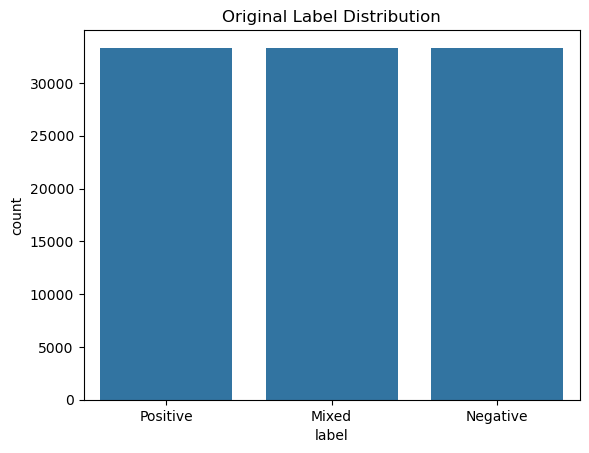

In [14]:
print(df["label"].value_counts())

sns.countplot(x="label", data=df)
plt.title("Original Label Distribution")
plt.show()

In [15]:
df = df[df["label"] != "Mixed"]

In [16]:
df["label"] = df["label"].map({
    "Negative": 0,
    "Positive": 1
})

print(df["label"].value_counts())

label
1    33333
0    33333
Name: count, dtype: int64


In [17]:
def clean_text(text):
    text = str(text).strip()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

In [18]:
df["clean_text"] = df["text"].apply(clean_text)

In [19]:
df.head()

,label,text,clean_text
0,1,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1,1,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2,1,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3,1,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4,1,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...


In [20]:
train_df, test_df = train_test_split(
    df,
    test_size=0.1,
    stratify=df["label"],
    random_state=42
)

print(len(train_df), len(test_df))

59999 6667


In [21]:
train_dataset = Dataset.from_pandas(train_df[["clean_text", "label"]])
test_dataset = Dataset.from_pandas(test_df[["clean_text", "label"]])

In [22]:
tokenizer = AutoTokenizer.from_pretrained("aubmindlab/bert-base-arabertv02")

In [ ]:
# tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")

In [23]:
def tokenize_function(example):
    return tokenizer(
        example["clean_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [24]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format("torch")
test_dataset.set_format("torch")

Map: 100%|██████████| 6667/6667 [00:00<00:00, 15474.16 examples/s]


In [25]:
model = AutoModelForSequenceClassification.from_pretrained(
    "aubmindlab/bert-base-arabertv02",
    num_labels=2
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7435.98it/s]
BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those param

In [34]:
import torch

print("Visible GPUs:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

Visible GPUs: 1
GPU 0: NVIDIA RTX 4500 Ada Generation


In [39]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [41]:
import evaluate

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="binary"
    )

    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"]
    }

In [42]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [43]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.239618,0.230428,0.908805,0.908157
2,0.191542,0.244956,0.906555,0.910758
3,0.148646,0.309628,0.912704,0.913522
4,0.108125,0.464636,0.910604,0.910859
5,0.076969,0.504354,0.899055,0.896446
6,0.058333,0.531073,0.906255,0.909276
7,0.033715,0.641779,0.906705,0.909250
8,0.029472,0.651866,0.908805,0.909685
9,0.011462,0.717007,0.907905,0.908495
10,0.004063,0.802088,0.910154,0.911351


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.88it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=37500, training_loss=0.09374606846173604, metrics={'train_runtime': 4111.1804, 'train_samples_per_second': 145.941, 'train_steps_per_second': 9.121, 'total_flos': 3.94660005263616e+16, 'train_loss': 0.09374606846173604, 'epoch': 10.0})

In [44]:
trainer.save_model("./final_model")
tokenizer.save_pretrained("./final_model")

Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.80s/it]


('./final_model\\tokenizer_config.json', './final_model\\tokenizer.json')